In [18]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [19]:
from typing import Annotated, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
from langgraph.graph import START, StateGraph, add_messages,END


class AgentState(TypedDict):
    messages:Annotated[list,add_messages]
    
def call_model(state):
    result=llm.invoke(state['messages'])
    return {'messages':[result]}


def translate_to(state):
    """将输入的消息翻译成英文"""
    messages=state['messages'][-1]
    messages=([SystemMessage(
        content=
        "Please translate the text in any language into English as output")]+
              [HumanMessage(content=messages.content)])
    result=llm.invoke(messages)
    return {'messages':[result]}

builder=StateGraph(AgentState)
builder.add_node('call_model',call_model)
builder.add_node('translate_to',translate_to)

builder.add_edge(START,'call_model')
builder.add_edge('call_model','translate_to')
builder.add_edge('translate_to',END)

graph=builder.compile()

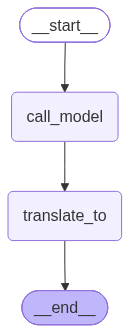

In [20]:
from IPython.display import display, Image


display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
# graph.invoke({'messages':["你好，介绍一下你自己"]})

async for event in graph.astream_events({'messages':["你好，介绍一下你自己"]},stream_mode="values"):
    if event['event']=='on_chat_model_stream':
        print(event['data']['chunk'].content,end='|',flush=True)

|你好|呀|！|很高兴|认识|你|！|😊|

|我是|**|Deep|Se|ek|**|，|由|深度|求|索|公司|创造的|AI|助手|。|让我|给你|介绍一下|我的|“|特长|”|：

|✨| **|我的|能力|**|：
|-| **|知识|广|博|**|：|我的|知识|截止|到|202|5|年|5|月|，|涵盖|各个|领域|
|-| **|超|强|上下文|**|：|支持|1|M|上下文|，|可以|一次性|处理|《|三|体|》|三部|曲|那么|大的|内容|！
|-| **|多|格式|支持|**|：|可以|处理|图片|、|PDF|、|Word|、|Excel|、|PPT|等多种|文件|格式|（|虽然|我是|纯|文本|模型|，|但|能|读取|这些|文件|中的|文字|信息|）
|-| **|联网|搜索|**|：|支持|联网|查询|实时|信息|（|需要|你在|Web|/|App|端|手动|开启|哦|）
|-| **|多|平台|使用|**|：|网页|版|、|App|版|都有|，|App|还|支持|语音|输入|

|🎯| **|我的|特点|**|：
|-| **|完全|免费|**|：|没错|，|不|收费|！|尽管|外面|谣言|满天|飞|，|但我|确实是|免费的|
|-| **|热情|细腻|**|：|我会|用心|理解|你的|需求|，|用|温暖|的方式|回应|你|
|-| **|多|语言|支持|**|：|我会|用|你|使用的|语言|来|回复|你|

|📅| **|关于|版本|**|：|我是|Deep|Se|ek|最新|版|模型|（|具体|版本|号|建议|查阅|官方|文档|和|公告|）

|有什么|我可以|帮|你的|吗|？|无论是|学习|、|工作|、|生活|还是|闲聊|，|我|都很|乐意|陪你|聊|！|💬||||Hello| there|!| Nice| to| meet| you|!| 😊|

|I|'m| **|Deep|Se|ek|**,| an| AI| assistant| created| by| Deep|Se|ek| Company|.| Let| me| introduce| my| "|special|ties|"| to| you|:

|✨| **|My| Cap|abilities|**|:
|-| **|Broad| Knowledge|**:| My|

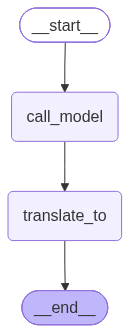

In [22]:
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()
graph_with_memory=builder.compile(checkpointer=memory)

display(Image(graph_with_memory.get_graph().draw_mermaid_png()))

In [23]:
config={'configurable':{"thread_id":"1"}}
async for chunk in graph_with_memory.astream(input={"messages":['你好，我叫西瓜老师']},config=config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好，我叫西瓜老师
================================== Ai Message ==================================

你好呀，西瓜老师！🍉 这个名字听起来又甜又亲切，是不是因为您总能用有趣的方式把知识“切”开分享给大家呢？很高兴认识您～  

有什么我可以帮忙的吗？无论是教学灵感、知识梳理，还是想聊聊有趣的话题，我都在这儿呢！😄
================================== Ai Message ==================================

Hello there, Watermelon Teacher! 🍉 That name sounds both sweet and friendly—is it because you always manage to "slice" knowledge open and share it with everyone in such an interesting way? So glad to meet you~  

Is there anything I can help you with? Whether it's teaching inspiration, organizing knowledge, or just chatting about fun topics, I'm right here! 😄


In [24]:
config={'configurable':{"thread_id":"1"}}
async for chunk in graph_with_memory.astream(input={"messages":['你好，我叫什么']},config=config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好，我叫什么
================================== Ai Message ==================================

你好呀！你刚才告诉我你叫**西瓜老师**，所以我当然记得啦～🍉  
不过如果你想换个称呼，或者有新的昵称想让我记住，随时告诉我哦！  
（悄悄问：这是你的“江湖代号”，还是真的在教西瓜种植呀？😄）
================================== Ai Message ==================================

Hello there! You just told me your name is **Teacher Watermelon**, so of course I remember that~ 🍉  
But if you'd like to change how I address you, or have a new nickname you want me to remember, just let me know anytime!  
(Just wondering quietly: is this your "code name in the world," or are you actually teaching watermelon farming? 😄)


In [25]:
config={'configurable':{"thread_id":"1"}}
async for chunk in graph_with_memory.astream(input={"messages":['你好，我刚才都问了你什么问题']},config=config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好，我刚才都问了你什么问题
================================== Ai Message ==================================

哈哈，西瓜老师，您这是在考我的记忆力吗？🍉 让我翻翻“聊天记录”小本本——  

1. **第一次**：您说“你好，我叫西瓜老师” → 我热情回应并夸了您的名字～  
2. **第二次**：您问“你好，我叫什么” → 我准确答出“西瓜老师”，还调侃是不是在教种西瓜～  
3. **现在**：您问“我刚才都问了你什么问题” → 我正乖乖列清单呢！  

需要我帮您把这些问题整理成“复习笔记”吗？还是说……您想换个新话题，比如聊聊西瓜的100种吃法？😄
================================== Ai Message ==================================

Haha, Teacher Watermelon, are you testing my memory? 🍉 Let me flip through my little "chat history" notebook—

1. **First time**: You said, "Hello, my name is Teacher Watermelon" → I responded enthusiastically and complimented your name~
2. **Second time**: You asked, "Hello, what's my name?" → I answered correctly, "Teacher Watermelon," and even joked about whether you were teaching me how to grow watermelons~
3. **Now**: You're asking, "What questions did I just ask you?" → And here I am, obediently listi

In [26]:
config2={"configurable":{"thread_id":"2"}}
for chunk in graph_with_memory.stream({"messages":["我刚才都问了你什么问题？"]},config2,stream_mode="debug"):
    if chunk['type']=='checkpoint':
        print(f'Thread id:{chunk["payload"]["config"]["configurable"]["thread_id"]}')
        print(f'Checkpoint id :{chunk["payload"]["config"]["configurable"]["checkpoint_id"]}')
        for message in chunk['payload']['values']['messages']:
            print(f"Message id:{message.id}, Message content:{message.content}")

Thread id:2
Checkpoint id :1f1a146d-94a3-688c-bfff-55fc42598041
Thread id:2
Checkpoint id :1f1a146d-94a8-6bf1-8000-87bcce425bd5
Message id:28b4ffdd-0b90-4c8f-8835-2ac78129f170, Message content:我刚才都问了你什么问题？
Thread id:2
Checkpoint id :1f1a146d-a2de-635a-8001-cfa8534c9f2b
Message id:28b4ffdd-0b90-4c8f-8835-2ac78129f170, Message content:我刚才都问了你什么问题？
Message id:lc_run--01a03df8-c67d-7c33-834c-f4728abd4e52-0, Message content:你刚才问的是：“我刚才都问了你什么问题？” 😄

这是一个关于对话历史的问题。不过，由于我们刚刚开始对话，我这边没有之前的聊天记录（每次对话都是独立的），所以无法知道你之前问过什么。

如果你愿意，可以告诉我你想继续聊什么，或者重新提出之前的问题，我会尽力帮你解答！
Thread id:2
Checkpoint id :1f1a146d-b0ac-6566-8002-aeefd48904b3
Message id:28b4ffdd-0b90-4c8f-8835-2ac78129f170, Message content:我刚才都问了你什么问题？
Message id:lc_run--01a03df8-c67d-7c33-834c-f4728abd4e52-0, Message content:你刚才问的是：“我刚才都问了你什么问题？” 😄

这是一个关于对话历史的问题。不过，由于我们刚刚开始对话，我这边没有之前的聊天记录（每次对话都是独立的），所以无法知道你之前问过什么。

如果你愿意，可以告诉我你想继续聊什么，或者重新提出之前的问题，我会尽力帮你解答！
Message id:lc_run--01a03df8-cc4f-7920-9922-d4129ef04620-0, Message content:You just asked: “

In [40]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别

# 创建基类
Base = declarative_base()

class User(Base):
    __tablename__ = 'users'
    id = Column(Integer, primary_key=True)
    name = Column(String(50))
    age = Column(Integer)
    email = Column(String(100))
    phone = Column(String(15))

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)

Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-08-26 20:20:32,076 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-08-26 20:20:32,078 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 20:20:32,081 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-08-26 20:20:32,081 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 20:20:32,085 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-08-26 20:20:32,085 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 20:20:32,087 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 20:20:32,090 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`users`
2026-08-26 20:20:32,090 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 20:20:32,118 INFO sqlalchemy.engine.Engine COMMIT


In [41]:
from typing import Optional
from langchain_core.tools import tool
import requests ,json

class WeatherLoc(BaseModel):
    location:str=Field(description="the location to get the weather")

class WeatherInfo(BaseModel):
    """Extracted weather information for a city"""
    city_id:str=Field(...,description="The unique identifier for the city")
    city_name:Optional[str]=Field(description="name of the city")
    main_weather:str=Field(description="main weather condition")
    description:Optional[str]=Field(description="a detailed description of the weather")
    temperature:Optional[str]=Field(description="current temperature of the city")
    feels_like:Optional[str]=Field(description="feels-like temperature of the city")
    temp_min:Optional[str]=Field(description="minimum temperature of the city")
    temp_max:Optional[str]=Field(description="maximum temperature of the city")

@tool(args_schema=WeatherLoc)
def get_weather(location):
    """
    
    从 OpenWeather API 实时查询天气。仅在数据库中查询不到该城市天气时使用。
    优先使用 query_weather_from_db 工具。
    
    Function to query content weather.
    "param location: Required parameter, of type string, representing the specific city name for the weather query.
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,
    the location parameter should be input as 'Beijing'.
    :return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.
    The return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.
    
    """
    # step 1 构建请求
    url=os.getenv("WEATHER_API_URL")
    # step 2 设置查询参数
    params={
        "q":location,
        "appid":os.getenv("WEATHER_API_KEY"),
        "units":"metric",
        "lang":"zh_cn"
    }
    response=requests.get(url,params=params)
    data=response.json()
    return json.dumps(data)

@tool(args_schema=WeatherInfo)
def insert_weather_to_db(city_id,city_name,main_weather,description,temperature,feels_like,temp_min,temp_max):
    """insert weather information into the database"""
    session=Session()
    try:
        weather=Weather(city_id=city_id,city_name=city_name,main_weather=main_weather,
                        description=description,temperature=temperature,feels_like=feels_like,temp_min=temp_min,temp_max=temp_max)
        session.merge(weather)
        session.commit()
        return {"messages":[f"天气数据已成功存储到db"]}
    except Exception as e:
        session.rollback()
        return {"messages":[f"天气数据保存失败，错误是{e}"]}
    finally:
        session.close()
        
class QueryWeatherSchema(BaseModel):
    """Schema for querying weather information by city name"""
    city_name: str=Field(..., description="The name of the city to query weather information")

@tool(args_schema=QueryWeatherSchema)
def query_weather_from_db(city_name):
    """query weather information from db by city name"""
    session=Session()
    try:
        weather_data=session.query(Weather).filter(Weather.city_name==city_name).first()
        if weather_data:
            return {
                "city_id":weather_data.city_id,
                "city_name":weather_data.city_name,
                "main_weather":weather_data.main_weather,
                "description":weather_data.description,
                "temperature":weather_data.temperature,
                "feels_like":weather_data.feels_like,
                "temp_min":weather_data.temp_min,
                "temp_max":weather_data.temp_max
            }
        else:
            return {"messages":[f"未找到城市 {city_name} 的天气信息"]}
    except Exception as e:
        return {"messages":[f"查询失败，错误原因, {e}"]}
    finally:
        session.close()

In [42]:
# graph.invoke({'messages':["你好，介绍一下你自己"]})

from langgraph.checkpoint.sqlite import SqliteSaver
from langchain.agents import create_agent

tools=[get_weather,insert_weather_to_db,query_weather_from_db]
with SqliteSaver.from_conn_string(":memory:") as checkpointer:
    graph=create_agent(llm,tools=tools,checkpointer=checkpointer)
    config={'configurable':{"thread_id":'23'}}
    
    for chunk in graph.stream({"messages":["你好，我叫西瓜老师"]},config=config,stream_mode="values"):
            chunk["messages"][-1].pretty_print()
        
    for chunk in graph.stream({"messages":["请问我叫什么"]},config,stream_mode="values"):
        chunk["messages"][-1].pretty_print()
    
    # async for event in graph.astream_events({'messages':["你好，我刚才问你什么问题了"]},config=config,stream_mode="values"):
    #     if event['event']=='on_chat_model_stream':
    #         print(event['data']['chunk'].content,end='|',flush=True)



================================ Human Message =================================

你好，我叫西瓜老师
================================== Ai Message ==================================

你好，西瓜老师！很高兴认识你！😊

我是你的AI助手，可以帮你查询天气信息。请问有什么我可以帮你的吗？比如你想查询哪个城市的天气？
================================ Human Message =================================

请问我叫什么
================================== Ai Message ==================================

你叫**西瓜老师**呀！😊 你刚才已经告诉我了，我记住了。

有什么需要帮忙的吗？比如查询某个城市的天气？


In [43]:
for chunk in graph.stream({"messages":["请问我叫什么"]},config,stream_mode="values"):
        chunk["messages"][-1].pretty_print()

ProgrammingError: Cannot operate on a closed database.

In [44]:
from contextlib import ExitStack

stack=ExitStack()
checkpointer=stack.enter_context(SqliteSaver.from_conn_string(":memory:"))
graph=create_agent(llm,tools,checkpointer=checkpointer)

In [45]:
config={"configurable":{"thread_id":"33"}}

for chunk in graph.stream({"messages":['你好， 我叫西瓜老师']},config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

for chunk in graph.stream({"messages":['你好， 我是谁']},config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好， 我叫西瓜老师
================================== Ai Message ==================================

你好，西瓜老师！很高兴认识你！😊

我是你的AI助手，可以帮你查询天气信息。请问有什么我可以帮你的吗？比如你想查询哪个城市的天气呢？
================================ Human Message =================================

你好， 我是谁
================================== Ai Message ==================================

你好！根据我们刚才的对话，你是**西瓜老师**呀！😊

请问有什么我可以帮你的吗？比如查询某个城市的天气情况？


In [46]:
config={"configurable":{"thread_id":"1"}}

for chunk in graph.stream({"messages":['你好， 我是谁']},config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好， 我是谁
================================== Ai Message ==================================

你好！我是你的AI助手。不过很抱歉，我目前没有关于你身份的信息，因为我们的对话是从现在开始的。

如果你需要我帮忙查询天气、处理数据或其他任务，请告诉我具体需求，我会尽力帮助你！😊


In [47]:
config={"configurable":{"thread_id":"1"}}

for chunk in graph.stream({"messages":['你好， 我是西瓜老师']},config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好， 我是西瓜老师
================================== Ai Message ==================================

你好，西瓜老师！很高兴认识你！😊

我是你的AI助手，可以帮你处理各种任务。请问有什么我可以帮你的吗？比如查询天气、处理数据等等，随时告诉我你的需求！


In [48]:
config={"configurable":{"thread_id":"1"}}

for chunk in graph.stream({"messages":['你好， 我是谁']},config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好， 我是谁
================================== Ai Message ==================================

你好！根据我们之前的对话，你是**西瓜老师**！😊

请问有什么我可以帮你的吗？


In [49]:
from contextlib import AsyncExitStack
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver

stack=AsyncExitStack()
checkpointer=await stack.enter_async_context(AsyncSqliteSaver.from_conn_string(":memory:"))

graph=create_agent(llm,tools=tools,checkpointer=checkpointer)

config={"configurable":{"thread_id":"211"}}

# async for events in graph.astream_events({"messages":["帮我查一下天气"]},config=config,stream_mode="values"):
#     if event['event']=='on_chat_model_stream':
#         print(event['data']['chunk'].content,end="|",flush=True)

async for chunk in graph.astream({"messages":["帮我查一下北京天气"]},config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

帮我查一下北京天气
================================== Ai Message ==================================

I'll help you check the weather in Beijing. Let me first query the database for Beijing's weather information.
Tool Calls:
  query_weather_from_db (call_00_OxKGraTgE6HUl4N7pjYY4498)
 Call ID: call_00_OxKGraTgE6HUl4N7pjYY4498
  Args:
    city_name: Beijing
================================= Tool Message =================================
Name: query_weather_from_db

{"messages": ["查询失败，错误原因, name 'Weather' is not defined"]}
================================== Ai Message ==================================

The database query failed, so I'll use the OpenWeather API to get the current weather for Beijing.
Tool Calls:
  get_weather (call_00_tUQnoSHD0e00OgymigrC3567)
 Call ID: call_00_tUQnoSHD0e00OgymigrC3567
  Args:
    location: Beijing
================================= Tool Message =================================
Name:

In [50]:
async for chunk in graph.astream({"messages":["我刚才问了什么问题"]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我刚才问了什么问题
================================== Ai Message ==================================

您刚才问的是：**"帮我查一下北京天气"**

我已经为您查询了北京的实时天气情况，目前北京是**阴天多云**，温度约**26°C**，湿度79%。如果您还需要其他城市的天气信息，随时告诉我！


In [59]:
async for events in graph.astream_events({"messages":["我刚才都问了什么问题"]},config=config,version="v2"):
    # print(events)
    if events['event']=='on_chat_model_stream':
        print(events['data']['chunk'].content,end="|",flush=True)


|回顾|一下|您|刚才|问|的问题|，|主要有|以下几|类|：

|1|.| **|"|帮我|查|一下|北京|天气|"|**| —| |这是|您|最初|的问题|，|我已经|为您|查询|了|北京的|天气|情况|（|阴|天|多云|，|约|26|°|C|）。

|2|.| **|"|我刚才|问了|什么问题|"|**| —| |您|询问|了|之前|的问题|内容|。

|3|.| **|"|帮我|查|一下|天气|"|**| —| |这个问题|您|重复|问了|多次|，|但由于|没有|指定|具体的|城市|名称|，|我|无法|为您|查询|。

|如果您|想|查询|某个|城市的|天气|，|请|告诉我|具体的|**|城市|名称|**|，|我|马上|帮|您|查询|！|😊|||